# Superstore Sales Analysis
### By Karen Letir | Google DA Certificate  | Harvard CS50P 

## Business Problem
A retail superstore wants to understand which products, regions, and customer 
segments are most and least profitable. This analysis identifies unprofitable 
areas and provides actionable recommendations to improve overall profitability.

## Dataset
- Source: Superstore Dataset (Kaggle)
- ~10,000 sales transactions
- Features: Order details, customer segments, product categories, regions, sales, profit, discount

## Tools
Python | pandas | matplotlib | seaborn

In [5]:
# Section 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded successfully")

Libraries loaded successfully


In [6]:
# Section 2: Load Data
df = pd.read_csv('/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv', 
                 encoding='latin-1')

# First look
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (9994, 21)

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
# Section 3: Data Overview
print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)

Shape: (9994, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State          

In [8]:
# Section 4: Data Cleaning
# Check for duplicates
print("Duplicate rows:", df.duplicated().sum())

# Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract year and month from Order Date
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month

# Check profit column
print("\nProfit range:")
print(df['Profit'].describe())

print("\nCleaning complete.")
print("Shape:", df.shape)

Duplicate rows: 0

Profit range:
count    9994.000000
mean       28.656896
std       234.260108
min     -6599.978000
25%         1.728750
50%         8.666500
75%        29.364000
max      8399.976000
Name: Profit, dtype: float64

Cleaning complete.
Shape: (9994, 23)


## Exploratory Data Analysis (EDA)
### Key Questions:
1. Which category and sub-category are most and least profitable?
2. Which region performs best and worst?
3. How does discount affect profit?
4. Which customer segment is most profitable?
5. What are the sales and profit trends over time?

/tmp/ipykernel_58/3221916638.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_profit.index, y=category_profit.values, palette='RdYlGn')


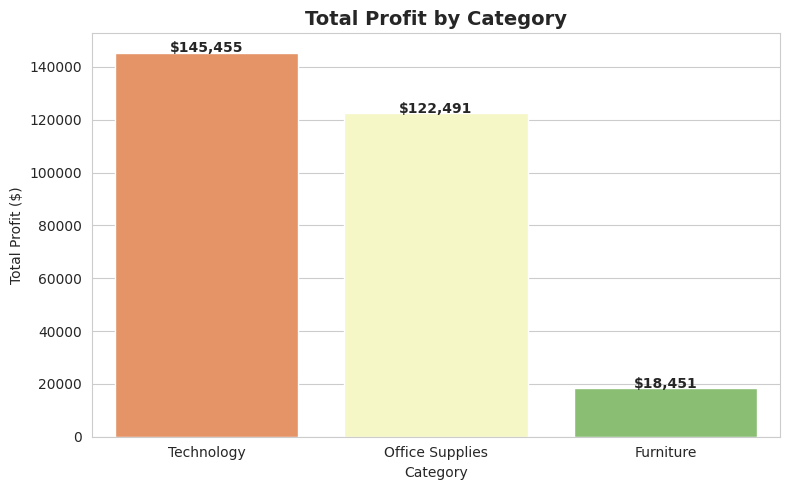

Profit by Category:
Category
Technology         145454.95
Office Supplies    122490.80
Furniture           18451.27
Name: Profit, dtype: float64


In [9]:
# Section 5: Profit by Category
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False).round(2)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_profit.index, y=category_profit.values, palette='RdYlGn')
plt.title('Total Profit by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Total Profit ($)')
for i, val in enumerate(category_profit.values):
    plt.text(i, val + 100, f'${val:,.0f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("Profit by Category:")
print(category_profit)

/tmp/ipykernel_58/279180531.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sub_profit.values, y=sub_profit.index, palette=colors)


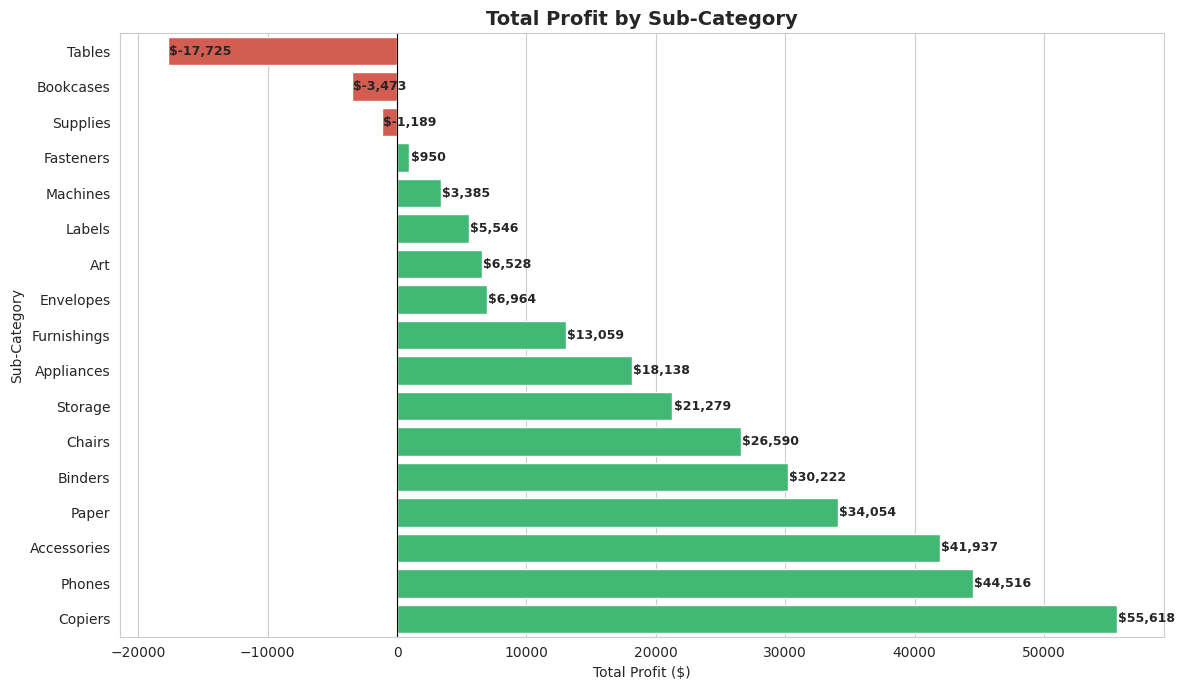

In [10]:
# Section 6: Profit by Sub-Category
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=True).round(2)

plt.figure(figsize=(12, 7))
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in sub_profit.values]
sns.barplot(x=sub_profit.values, y=sub_profit.index, palette=colors)
plt.title('Total Profit by Sub-Category', fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.ylabel('Sub-Category')
plt.axvline(x=0, color='black', linewidth=0.8)
for i, val in enumerate(sub_profit.values):
    plt.text(val + 100, i, f'${val:,.0f}', va='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()

/tmp/ipykernel_58/804755900.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_profit.index, y=region_profit.values, palette='Blues_r', ax=axes[0])
/tmp/ipykernel_58/804755900.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_margin.index, y=region_margin.values, palette='Greens_r', ax=axes[1])


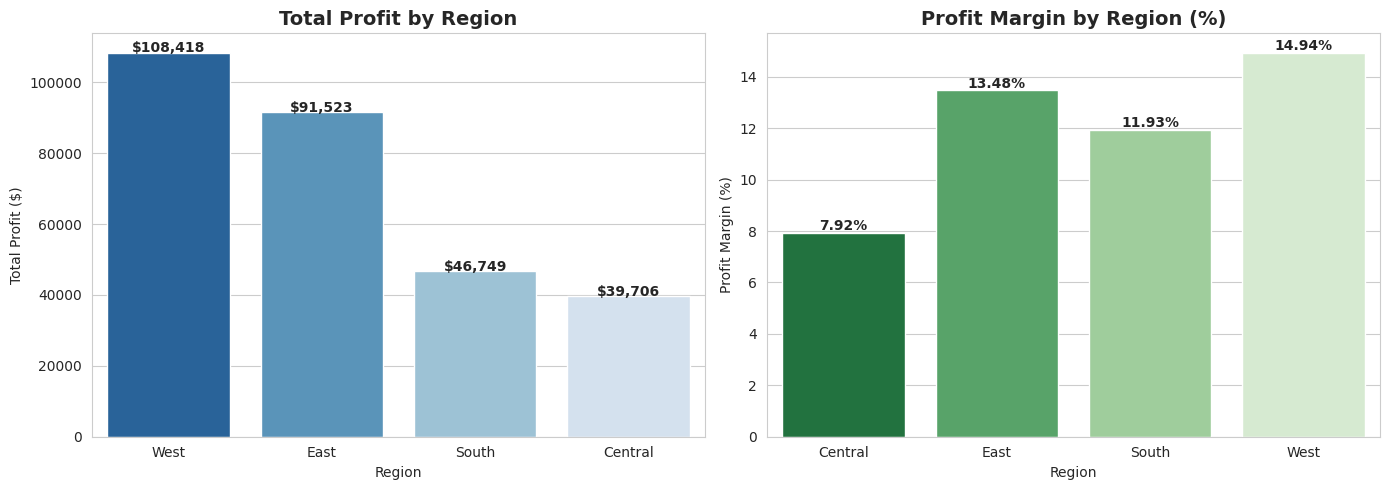

In [11]:
# Section 7: Profit by Region
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False).round(2)
region_sales = df.groupby('Region')['Sales'].sum().round(2)
region_margin = (region_profit / region_sales * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total Profit by Region
sns.barplot(x=region_profit.index, y=region_profit.values, palette='Blues_r', ax=axes[0])
axes[0].set_title('Total Profit by Region', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Total Profit ($)')
for i, val in enumerate(region_profit.values):
    axes[0].text(i, val + 100, f'${val:,.0f}', ha='center', fontweight='bold')

# Profit Margin by Region
sns.barplot(x=region_margin.index, y=region_margin.values, palette='Greens_r', ax=axes[1])
axes[1].set_title('Profit Margin by Region (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Profit Margin (%)')
for i, val in enumerate(region_margin.values):
    axes[1].text(i, val + 0.1, f'{val}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

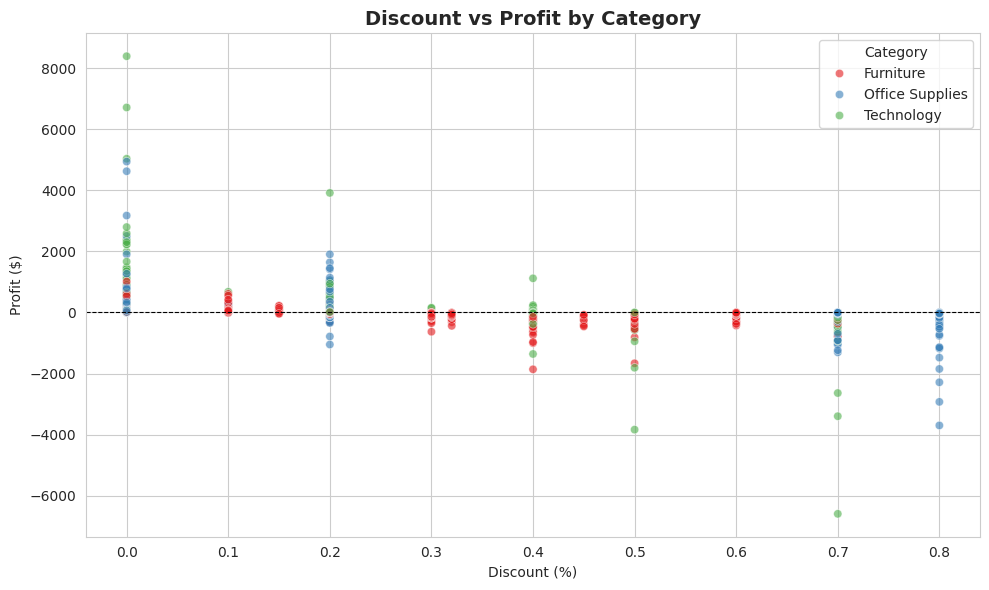

Average Profit by Discount Level:
Discount_Bucket
0%         66.90
1-10%      96.06
11-20%     24.74
21-30%    -45.68
31-40%   -109.22
41-50%   -298.70
51%+      -89.44
Name: Profit, dtype: float64


/tmp/ipykernel_58/1882182837.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_profit = df.groupby('Discount_Bucket')['Profit'].mean().round(2)


In [12]:
# Section 8: Discount vs Profit
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', 
                hue='Category', alpha=0.6, palette='Set1')
plt.title('Discount vs Profit by Category', fontsize=14, fontweight='bold')
plt.xlabel('Discount (%)')
plt.ylabel('Profit ($)')
plt.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

# Average profit by discount bucket
df['Discount_Bucket'] = pd.cut(df['Discount'], 
                                bins=[-0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.9],
                                labels=['0%', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '51%+'])

discount_profit = df.groupby('Discount_Bucket')['Profit'].mean().round(2)
print("Average Profit by Discount Level:")
print(discount_profit)

/tmp/ipykernel_58/1011885256.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_profit.index, y=segment_profit.values, palette='Purples_r')


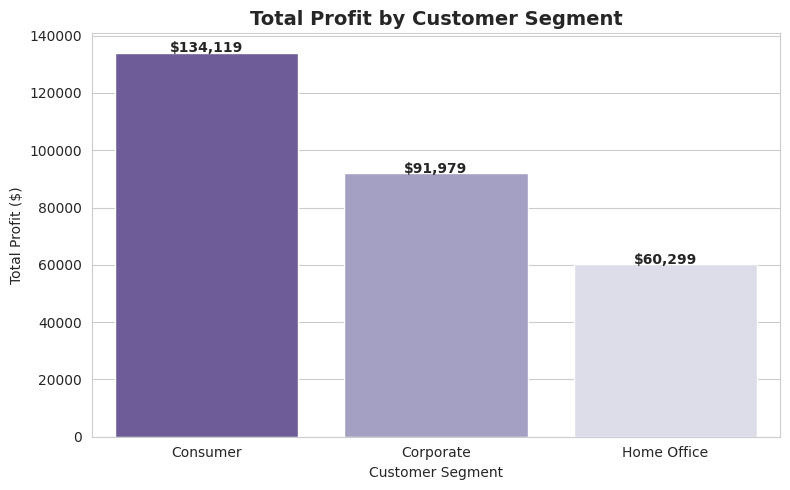

Profit Margin by Segment:
Segment
Consumer       11.55
Corporate      13.03
Home Office    14.03
dtype: float64


In [13]:
# Section 9: Profit by Customer Segment
segment_profit = df.groupby('Segment')['Profit'].sum().sort_values(ascending=False).round(2)
segment_sales = df.groupby('Segment')['Sales'].sum().round(2)
segment_margin = (segment_profit / segment_sales * 100).round(2)

plt.figure(figsize=(8, 5))
sns.barplot(x=segment_profit.index, y=segment_profit.values, palette='Purples_r')
plt.title('Total Profit by Customer Segment', fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment')
plt.ylabel('Total Profit ($)')
for i, val in enumerate(segment_profit.values):
    plt.text(i, val + 100, f'${val:,.0f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("Profit Margin by Segment:")
print(segment_margin)

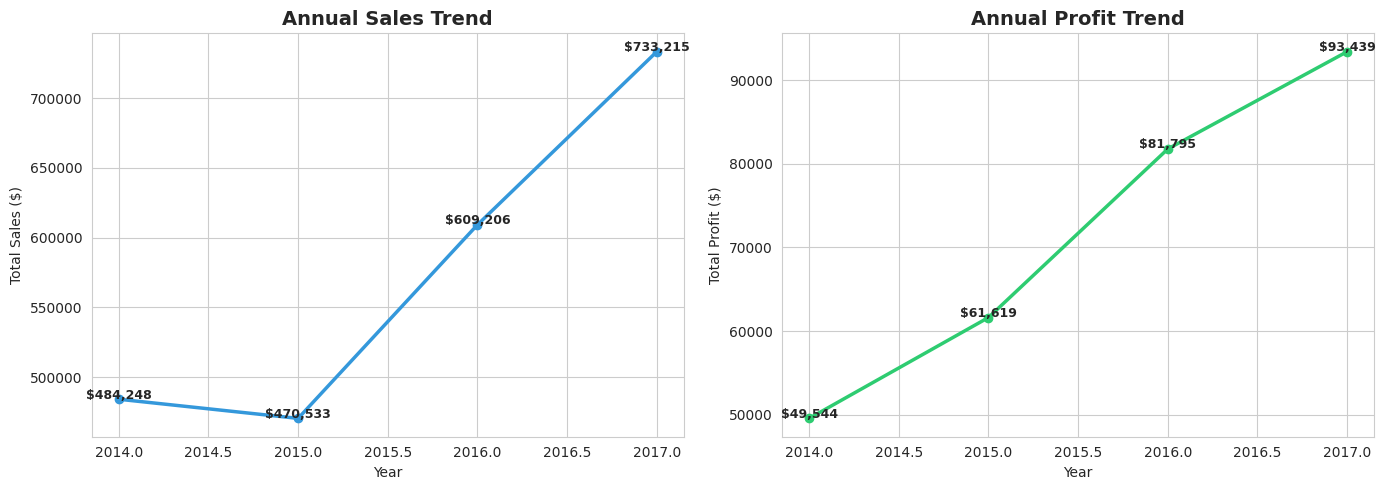

In [14]:
# Section 10: Sales and Profit Trend Over Time
yearly = df.groupby('Order Year')[['Sales', 'Profit']].sum().round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sales trend
axes[0].plot(yearly.index, yearly['Sales'], marker='o', color='#3498db', linewidth=2.5)
axes[0].set_title('Annual Sales Trend', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Sales ($)')
for x, y in zip(yearly.index, yearly['Sales']):
    axes[0].text(x, y + 500, f'${y:,.0f}', ha='center', fontweight='bold', fontsize=9)

# Profit trend
axes[1].plot(yearly.index, yearly['Profit'], marker='o', color='#2ecc71', linewidth=2.5)
axes[1].set_title('Annual Profit Trend', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Profit ($)')
for x, y in zip(yearly.index, yearly['Profit']):
    axes[1].text(x, y + 100, f'${y:,.0f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

## Key Findings
1. **Technology** is the most profitable category; **Furniture** is the least profitable
2. **Tables and Bookcases** are the most unprofitable sub-categories — losing money consistently
3. **West region** has the highest total profit; **Central region** has the lowest profit margin
4. **High discounts (>20%) directly destroy profit** — negative average profit at 31%+ discounts
5. **Consumer segment** generates the most revenue but **Corporate** has a stronger profit margin
6. **Sales and profit are both growing year over year** — business is trending positively

## Business Recommendations
1. **Stop or reduce deep discounts** — anything above 20% consistently produces losses
2. **Discontinue or reprice Tables and Bookcases** — both sub-categories are loss-making
3. **Double down on Technology** — highest profit margin, strong growth opportunity
4. **Focus marketing on Corporate segment** — stronger margins than Consumer
5. **Invest in West region strategies** and investigate why Central underperforms

In [15]:
# Section 11: Summary Statistics
print("=" * 55)
print("SUPERSTORE SALES ANALYSIS - SUMMARY")
print("=" * 55)
print(f"\nTotal Orders: {len(df):,}")
print(f"Total Sales: ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Overall Profit Margin: {(df['Profit'].sum()/df['Sales'].sum()*100):.2f}%")

print(f"\nMost Profitable Category: {category_profit.index[0]} (${category_profit.values[0]:,.2f})")
print(f"Least Profitable Category: {category_profit.index[-1]} (${category_profit.values[-1]:,.2f})")

print(f"\nMost Profitable Region: {region_profit.index[0]} (${region_profit.values[0]:,.2f})")
print(f"Least Profitable Region: {region_profit.index[-1]} (${region_profit.values[-1]:,.2f})")

print(f"\nMost Profitable Segment: {segment_profit.index[0]} (${segment_profit.values[0]:,.2f})")

print(f"\nAvg Profit at 0% Discount: ${discount_profit['0%']:,.2f}")
print(f"Avg Profit at 51%+ Discount: ${discount_profit['51%+']:,.2f}")
print("=" * 55)

SUPERSTORE SALES ANALYSIS - SUMMARY

Total Orders: 9,994
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Overall Profit Margin: 12.47%

Most Profitable Category: Technology ($145,454.95)
Least Profitable Category: Furniture ($18,451.27)

Most Profitable Region: West ($108,418.45)
Least Profitable Region: Central ($39,706.36)

Most Profitable Segment: Consumer ($134,119.21)

Avg Profit at 0% Discount: $66.90
Avg Profit at 51%+ Discount: $-89.44
